# Infraslow fluctuation of sigma power (ISFS) — YASA demo

Reproduces the analyses behind **infraslow fluctuation of sigma power (ISFS)** using
this repo's `infraslow` package with the YASA spindle detector, as eight figures:

- **Figure 1 — spindle detection.** Detector quality-control panels: (A) grand-average
  spindle waveform time-locked to each spindle's peak, (B) time-frequency power
  spindle-locked, (C) relative sigma-band (10–16 Hz) power spindle-locked, normalized to
  the pre-spindle baseline.
- **Figure 2 — slow wave detection.** Detector quality-control panels for
  `infraslow.processing.sws.sw_detect`: (A) grand-average slow-wave waveform time-locked
  to each wave's negative peak, (B) time-frequency power slow-wave-locked, (C) relative
  delta-band (0.5–4 Hz) power slow-wave-locked, normalized to the pre-wave baseline.
  Restricted to NREM sleep (N2+N3).
- **Figure 3 — hypnogram and raw EEG with detected spindles.** Hypnogram with NREM-2
  bouts ≥ 200 s that contain ≥1 detected spindle highlighted (green), and the raw EEG
  time series of one such bout with detected spindles marked in blue.
- **Figure 4 — sigma-power time course.** The sigma-power (10–16 Hz) time course over
  the same window as Figure 3, spindles marked as blue dots.
- **Figure 5 — relative spectral power, baseline correction & bi-Gaussian fit.** Relative
  spectral power of the sigma-power course (baseline-corrected over 0.06–0.1 Hz), with a
  bi-Gaussian fit giving peak frequency, bandwidth and area under the curve.
- **Figure 6 — distribution of peak frequency across bouts.** Histogram of each
  individual N2 bout's own within-band spectral peak frequency, showing how consistent
  the ISFS peak frequency is bout-to-bout, against Figure 5's across-bout mean-spectrum
  peak and bi-Gaussian fit peak.
- **Figure 7 — Morlet wavelet phase (infraslow band).** Instantaneous phase, at the
  fitted ISFS peak frequency, of the infraslow-band (0.01–0.1 Hz) Morlet wavelet
  decomposition of the sigma-power envelope, over the same window as Figures 3 and 4,
  with 8 shaded phase bins.
- **Figure 8 — filtered sigma power, standardization & phase bins.** The sigma-power
  course band-pass filtered to the infraslow band, standardized, and divided into eight
  phase bins (1–4 negative half wave, 5–8 positive half wave).

> The package derives the sigma-power course from the **Hilbert** analytic power of the
> 10–16 Hz band — a practical stand-in for the paper's wavelet-derived sigma power.

In [3]:
%reset -f

In [4]:
import mne
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch, ConnectionPatch
from scipy.signal import find_peaks

from infraslow import BioserenityPSGLoader
from infraslow.processing.spindle import (
    spindles_detect,
    _extract_epoch_stages,
    _stages_to_int,
    DEFAULT_STAGE_MAP,
    DEFAULT_EPOCH_SEC,
)
from infraslow.processing.sws import sw_detect
from infraslow.processing.infraslow import (
    eeg_envelope,
    _wavelet_freqs,
    _wavelet_n_cycles,
    infraslow_spectrum,
    relative_power,
    baseline_correct,
    bigaussian,
    fit_isfs,
    isfs_lowpass,
    DEFAULT_SF_ENV,
)
from infraslow.viz import plot_hypnogram

plt.rcParams['figure.dpi'] = 110
PURPLE, LPURPLE, BLUE = '#5b2a86', '#c9b3e6', 'tab:blue'

## Load one subject and detect spindles

In [5]:
SUBJECT = '318679'
CHANNEL = 'C3'
SF = 200
SIGMA_BAND = (11.0, 16.0)      # Figure 4: sigma power = |power| averaged over 11-16 Hz
INFRASLOW_BAND = (0.01, 0.1)   # ISFS search band
BASELINE_BAND = (0.06, 0.1)    # Figure 5: baseline-correction band (red line)
MIN_BOUT_SEC = 200             # Figure 3: consecutive artifact-free N2 bouts >= 200 s
WINDOW_SEC = 100
EPOCH_SEC = DEFAULT_EPOCH_SEC  # 30 s scored epochs
ISFS_PERIOD = (25.0, 100.0)    # Figure 8: infraslow time scale (s)

loader = BioserenityPSGLoader(
    subject_id=SUBJECT, sf=SF, requested_channels=[CHANNEL]
).load()
data = np.asarray(loader.get_channel(CHANNEL), dtype=float)
sf = float(loader.sf)
duration_sec = len(data) / sf

print(f'{SUBJECT} {CHANNEL}: {len(data)} samples @ {sf:g} Hz = {duration_sec/60:.1f} min')

initiated lunapi 1.4.0 <lunapi.lunapi0.luna object at 0x7f8378fdb530> 



  *** warning, signal 13 ( TFlo ) has a non-integer SR
  *** may wish to use RECORD-SIZE if this is due to a fractional EDF record size
  *** (it will resample signals to fit in a new regular, e.g. dur=1, record size)
    - record size        = 2 seconds
    - samples per record = 25
    - implied SR         = 25 / 2 = 12.5
  *** warning, signal 14 ( CFlo ) has a non-integer SR
  *** may wish to use RECORD-SIZE if this is due to a fractional EDF record size
  *** (it will resample signals to fit in a new regular, e.g. dur=1, record size)
    - record size        = 2 seconds
    - samples per record = 25
    - implied SR         = 25 / 2 = 12.5
  *** warning, signal 15 ( Tho ) has a non-integer SR
  *** may wish to use RECORD-SIZE if this is due to a fractional EDF record size
  *** (it will resample signals to fit in a new regular, e.g. dur=1, record size)
    - record size        = 2 seconds
    - samples per record = 25
    - implied SR         = 25 / 2 = 12.5
  *** warning, signal 1

318679 C3: 5502000 samples @ 200 Hz = 458.5 min


In [6]:
def nrem2_bouts(loader, *, epoch_sec=EPOCH_SEC, min_dur=MIN_BOUT_SEC, stage_code=2):
    """(start, stop) times (s) of runs of consecutive N2 epochs lasting >= min_dur."""
    codes = _stages_to_int(
        _extract_epoch_stages(loader.annotations, stage_column='stage'),
        DEFAULT_STAGE_MAP,
    )
    bouts, i, n = [], 0, len(codes)
    while i < n:
        if codes[i] == stage_code:
            j = i
            while j < n and codes[j] == stage_code:
                j += 1
            if (j - i) * epoch_sec >= min_dur:
                bouts.append((i * epoch_sec, j * epoch_sec))
            i = j
        else:
            i += 1
    return bouts

bouts_all = nrem2_bouts(loader)
print(f'{len(bouts_all)} NREM2 bout(s) >= {MIN_BOUT_SEC:g}s (before spindle filter)')

# Figures 1/3/4: sleep spindles on C3, restricted to N2, detected with YASA.
sp = spindles_detect(loader, ch_names=CHANNEL, include=(2,))
peaks = sp.summary()['Peak'].to_numpy()
starts = sp.summary()['Start'].to_numpy()
ends = sp.summary()['End'].to_numpy()
print(f'{len(peaks)} spindles detected')

# Infraslow uses ONLY N2 bouts that contain >= 1 detected spindle
# (spindle-free bouts are dropped).
bouts = [(a, b) for a, b in bouts_all if np.any((peaks >= a) & (peaks < b))]
total_min = sum(b - a for a, b in bouts) / 60
print(f'{len(bouts)}/{len(bouts_all)} bout(s) contain >= 1 spindle; total {total_min:.1f} min')

24 NREM2 bout(s) >= 200s (before spindle filter)


02-Aug-26 20:17:59 | WARNING | Hypnogram is SHORTER than data by 30.00 seconds. Padding hypnogram with Unscored (UNS) to match data.size.


308 spindles detected
23/24 bout(s) contain >= 1 spindle; total 191.0 min


In [7]:
sp.summary()

,Start,Peak,End,Duration,Amplitude,AmpFiltered,RMS,AbsPower,RelPower,Frequency,Oscillations,Symmetry,Stage,Channel,IdxChannel
0,2038.280,2038.610,2038.990,0.710,73.216180,37.271157,14.622752,2.299767,0.299448,12.598472,8.0,0.461538,2,C3,0
1,2071.295,2071.390,2071.845,0.550,37.214565,26.982883,8.354340,1.926319,0.320537,12.326332,7.0,0.171171,2,C3,0
2,2075.430,2075.580,2076.320,0.890,44.000876,25.152467,9.603135,1.861553,0.287332,13.490147,10.0,0.167598,2,C3,0
3,2079.105,2079.325,2079.845,0.740,34.813440,22.616473,8.630381,1.679920,0.256194,13.317881,9.0,0.295302,2,C3,0
4,2194.745,2195.620,2195.940,1.195,51.941857,23.433614,8.761249,1.516599,0.229598,12.781315,13.0,0.729167,2,C3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
303,25904.045,25904.145,25905.250,1.205,40.460514,19.834691,7.875777,1.723145,0.303694,12.817498,15.0,0.082645,2,C3,0
304,25934.270,25934.600,25934.795,0.525,32.721881,19.496546,8.517722,1.847604,0.225432,13.737264,6.0,0.622642,2,C3,0
305,25940.205,25940.365,25941.515,1.310,66.081999,33.279827,12.050749,1.755196,0.287395,12.280751,14.0,0.121673,2,C3,0
306,26010.835,26011.265,26011.435,0.600,59.743275,35.744540,12.709183,2.202982,0.372866,12.999043,8.0,0.710744,2,C3,0


## Figure 1 — spindle detection

Quality-control panels for the YASA spindle detector, pooling every detected spindle on
`CHANNEL` and centering each on its own `Peak`. **A** — grand-average raw-EEG waveform
(`sp.plot_average`, mean ± 95% CI). **B** — time-frequency power, spindle-locked (Morlet
wavelet, 6–24 Hz); the cyan box marks the sigma band. **C** — relative sigma-band
(10–16 Hz) power, spindle-locked, normalized to the pre-spindle (< -0.5 s) baseline.

In [8]:
# Quick sanity check with YASA's own averaging/plotting (Panel A, reproduced below
# with matched styling so it can sit alongside Panels B and C in one figure).
# sp.plot_average(center='Peak', time_before=1, time_after=1);

In [9]:
# --- Fig 1 params: time-locked window around each spindle's Peak ---
TL_BEFORE, TL_AFTER = 1.0, 1.0     # seconds before/after the spindle Peak (A, B, C)
TF_FREQS = np.arange(6, 26, 2.0)   # Fig 1B: Morlet wavelet centre frequencies (Hz)
BASELINE_WIN = (-1.0, -0.5)        # Fig 1C: pre-spindle baseline window (s)

# Common time axis for every sp.get_sync_events(...) call at this before/after/sf.
bef, aft = int(sf * TL_BEFORE), int(sf * TL_AFTER)
tl_time = np.arange(-bef, aft + 1) / sf

# A) Raw EEG, spindle-locked -- (n_spindles, n_times), same data as sp.plot_average above.
sync_raw = sp.get_sync_events(center='Peak', time_before=TL_BEFORE, time_after=TL_AFTER,
                               as_dataframe=False)[0]
n_spindles = sync_raw.shape[0]

# B) Time-frequency: Morlet wavelet power (dB), averaged across spindles. n_cycles scales
# with frequency (matches infraslow.eeg_envelope's wavelet=True path) for better frequency
# resolution at higher TF_FREQS.
n_cycles_tf = np.clip(TF_FREQS / 2.0, 3.0, None)
tfr_b = mne.time_frequency.tfr_array_morlet(
    sync_raw[:, np.newaxis, :], sfreq=sf, freqs=TF_FREQS, n_cycles=n_cycles_tf,
    output='power', zero_mean=True, verbose=False,
)
tf_db = 10 * np.log10(tfr_b[:, 0].mean(axis=0))

# C) Relative sigma-band (11-16 Hz) power, spindle-locked, normalized to baseline.
sigma_freqs = np.arange(SIGMA_BAND[0], SIGMA_BAND[1] + 1e-9, 1.0)
n_cycles_sigma = np.clip(sigma_freqs / 2.0, 3.0, None)
tfr_c = mne.time_frequency.tfr_array_morlet(
    sync_raw[:, np.newaxis, :], sfreq=sf, freqs=sigma_freqs, n_cycles=n_cycles_sigma,
    output='power', zero_mean=True, verbose=False,
)
sigma_power = tfr_c[:, 0].mean(axis=1)
base_m = (tl_time >= BASELINE_WIN[0]) & (tl_time < BASELINE_WIN[1])
rel_sigma = sigma_power / sigma_power[:, base_m].mean(axis=1, keepdims=True)

print(f'Fig 1: {n_spindles} spindles, {len(TF_FREQS)} TF freqs '
      f'({TF_FREQS[0]:g}-{TF_FREQS[-1]:g} Hz)')

Fig 1: 308 spindles, 10 TF freqs (6-24 Hz)


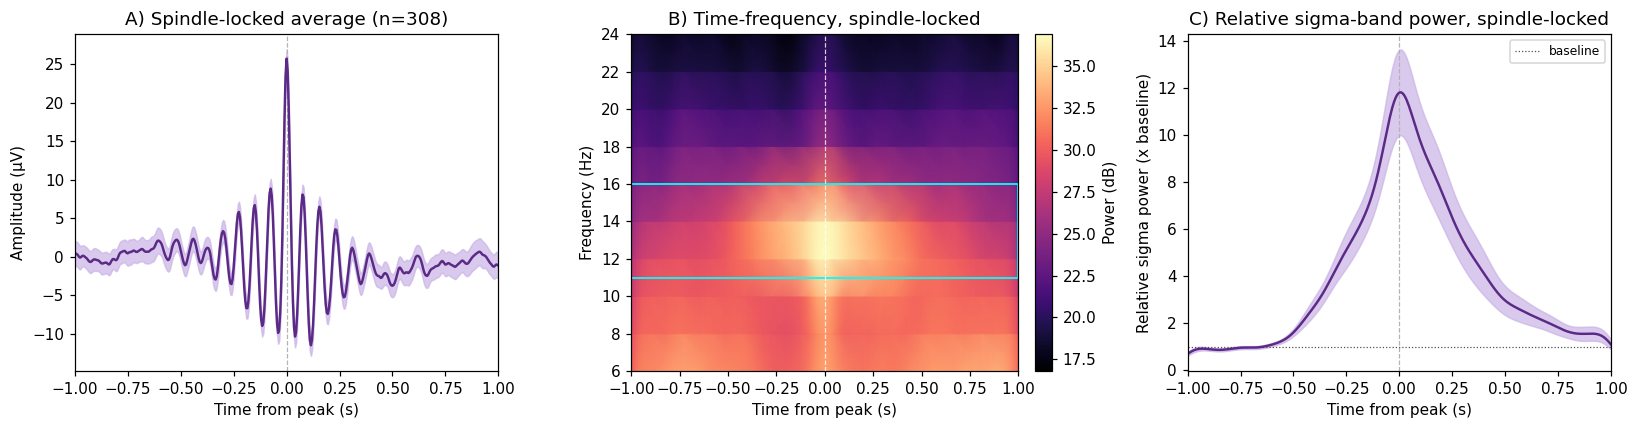

In [10]:
fig, (axA, axB, axC) = plt.subplots(1, 3, figsize=(15, 4))

# --- A) Spindle-locked average raw EEG (mean +/- 95% CI) ---
mean_raw = sync_raw.mean(axis=0)
ci_raw = 1.96 * sync_raw.std(axis=0, ddof=1) / np.sqrt(n_spindles)
axA.axvline(0, color='0.7', lw=0.8, ls='--')
axA.fill_between(tl_time, mean_raw - ci_raw, mean_raw + ci_raw, color=LPURPLE, alpha=0.7)
axA.plot(tl_time, mean_raw, color=PURPLE, lw=1.6)
axA.set(xlim=(tl_time[0], tl_time[-1]), xlabel='Time from peak (s)', ylabel='Amplitude (µV)',
        title=f'A) Spindle-locked average (n={n_spindles})')

# --- B) Time-frequency, spindle-locked (Morlet wavelet power) ---
im = axB.pcolormesh(tl_time, TF_FREQS, tf_db, shading='gouraud', cmap='magma')
axB.axvline(0, color='w', lw=0.8, ls='--', alpha=0.8)
axB.axhspan(SIGMA_BAND[0], SIGMA_BAND[1], facecolor='none', edgecolor='cyan', lw=1.2)
axB.set(xlim=(tl_time[0], tl_time[-1]), xlabel='Time from peak (s)', ylabel='Frequency (Hz)',
        title='B) Time-frequency, spindle-locked')
fig.colorbar(im, ax=axB, label='Power (dB)', fraction=0.046, pad=0.04)

# --- C) Relative sigma-band power, spindle-locked ---
mean_rel = rel_sigma.mean(axis=0)
ci_rel = 1.96 * rel_sigma.std(axis=0, ddof=1) / np.sqrt(n_spindles)
axC.axvline(0, color='0.7', lw=0.8, ls='--')
axC.axhline(1, color='0.3', lw=0.8, ls=':', label='baseline')
axC.fill_between(tl_time, mean_rel - ci_rel, mean_rel + ci_rel, color=LPURPLE, alpha=0.7)
axC.plot(tl_time, mean_rel, color=PURPLE, lw=1.6)
axC.set(xlim=(tl_time[0], tl_time[-1]), xlabel='Time from peak (s)',
        ylabel='Relative sigma power (x baseline)',
        title='C) Relative sigma-band power, spindle-locked')
axC.legend(loc='upper right', frameon=True, fontsize=8)

fig.tight_layout()

## Figure 2 — slow wave detection

Quality-control panels for the YASA slow-wave detector (`infraslow.processing.sws.sw_detect`,
a thin wrapper over `yasa.sw_detect` mirroring how `spindles_detect` wraps
`yasa.spindles_detect`), pooling every detected slow wave on `CHANNEL` (N2,
YASA's own `include=(2)` default) and centering each on its own `NegPeak`. **A** —
grand-average raw-EEG waveform (mean ± 95% CI). **B** — time-frequency power,
slow-wave-locked (Morlet wavelet, 0.5–16 Hz); the cyan box marks the delta/slow-wave band.
**C** — relative delta-band (0.5–4 Hz) power, slow-wave-locked, normalized to the
pre-wave baseline.

In [11]:
# Slow waves on C3, restricted to N2.
sw = sw_detect(loader, ch_names=CHANNEL,  include=(2,))
print(f'{len(sw.summary())} slow waves detected')

02-Aug-26 20:18:03 | WARNING | Hypnogram is SHORTER than data by 30.00 seconds. Padding hypnogram with Unscored (UNS) to match data.size.


192 slow waves detected


In [12]:
# --- Fig 2 params: time-locked windows around each slow wave's NegPeak ---
SW_BEFORE, SW_AFTER = 0.4, 0.8           # A) narrow window for the raw-average waveform
                                          # (YASA's own sw_detect plot_average default)
SW_TF_BEFORE, SW_TF_AFTER = 5.0, 5.0     # B)/C) wider window: a 0.5 Hz Morlet wavelet needs
                                          # ~1273 samples (~6.4 s) of context to resolve --
                                          # far more than A's window can provide.
TF_FREQS_SW = np.arange(0.5, 16.5, 1.5)  # Fig 2B: Morlet wavelet centre frequencies (Hz)
DELTA_BAND = (0.5, 4.0)                  # Fig 2B/C: delta/slow-wave band (cyan box in B)
BASELINE_WIN_SW = (-4.5, -3.5)           # Fig 2C: pre-wave baseline window (s), inside the
                                          # wide TF window, clear of its edges

# A) Raw EEG, slow-wave-locked -- (n_sw, n_times), narrow window for a clean waveform plot.
sync_sw = sw.get_sync_events(center='NegPeak', time_before=SW_BEFORE, time_after=SW_AFTER,
                              as_dataframe=False)[0]
n_sw = sync_sw.shape[0]
bef_sw, aft_sw = int(sf * SW_BEFORE), int(sf * SW_AFTER)
sw_time = np.arange(-bef_sw, aft_sw + 1) / sf

# B)/C) Wider window so the low-frequency Morlet wavelets fit within the signal length.
sync_sw_tf = sw.get_sync_events(center='NegPeak', time_before=SW_TF_BEFORE, time_after=SW_TF_AFTER,
                                 as_dataframe=False)[0]
bef_tf, aft_tf = int(sf * SW_TF_BEFORE), int(sf * SW_TF_AFTER)
sw_time_tf = np.arange(-bef_tf, aft_tf + 1) / sf

# B) Time-frequency: Morlet wavelet power (dB), averaged across slow waves. n_cycles uses
# a lower floor than Fig 1B (2 vs 3) since these are much lower frequencies.
n_cycles_tf_sw = np.clip(TF_FREQS_SW / 2.0, 2.0, None)
tfr_b_sw = mne.time_frequency.tfr_array_morlet(
    sync_sw_tf[:, np.newaxis, :], sfreq=sf, freqs=TF_FREQS_SW, n_cycles=n_cycles_tf_sw,
    output='power', zero_mean=True, verbose=False,
)
tf_db_sw = 10 * np.log10(tfr_b_sw[:, 0].mean(axis=0))

# C) Relative delta-band (0.5-4 Hz) power, slow-wave-locked, normalized to baseline.
delta_freqs = np.arange(DELTA_BAND[0], DELTA_BAND[1] + 1e-9, 0.5)
n_cycles_delta = np.clip(delta_freqs / 2.0, 2.0, None)
tfr_c_sw = mne.time_frequency.tfr_array_morlet(
    sync_sw_tf[:, np.newaxis, :], sfreq=sf, freqs=delta_freqs, n_cycles=n_cycles_delta,
    output='power', zero_mean=True, verbose=False,
)
delta_power = tfr_c_sw[:, 0].mean(axis=1)
base_m_sw = (sw_time_tf >= BASELINE_WIN_SW[0]) & (sw_time_tf < BASELINE_WIN_SW[1])
rel_delta = delta_power / delta_power[:, base_m_sw].mean(axis=1, keepdims=True)

print(f'Fig 2: {n_sw} slow waves, {len(TF_FREQS_SW)} TF freqs '
      f'({TF_FREQS_SW[0]:g}-{TF_FREQS_SW[-1]:g} Hz)')

Fig 2: 192 slow waves, 11 TF freqs (0.5-15.5 Hz)


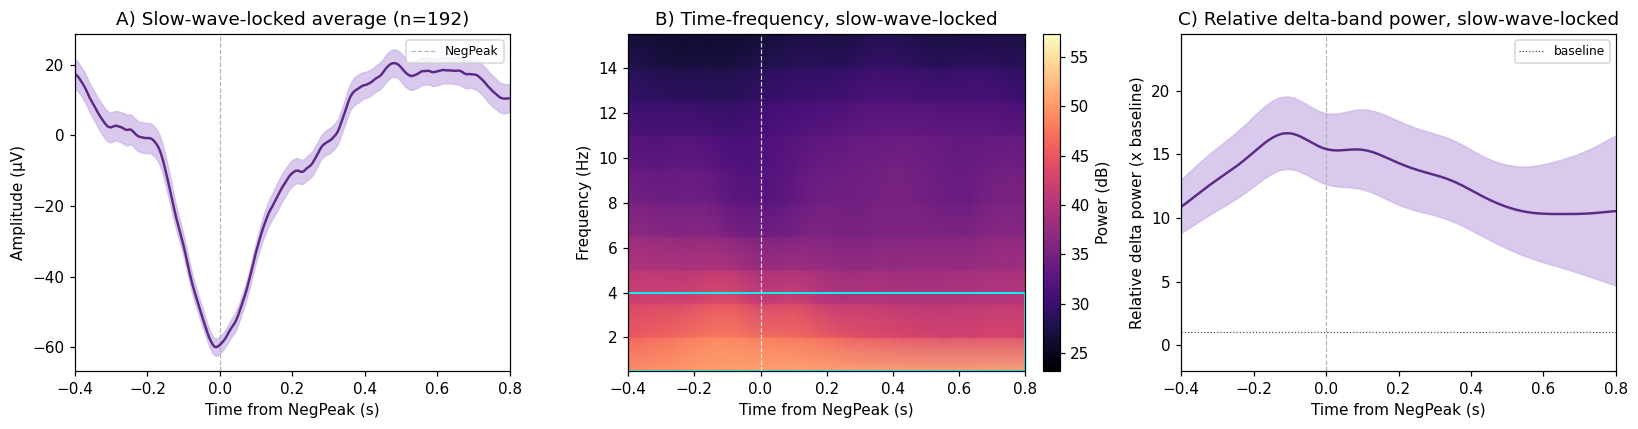

In [13]:
fig, (axA, axB, axC) = plt.subplots(1, 3, figsize=(15, 4))

# --- A) Slow-wave-locked average raw EEG (mean +/- 95% CI) ---
mean_sw = sync_sw.mean(axis=0)
ci_sw = 1.96 * sync_sw.std(axis=0, ddof=1) / np.sqrt(n_sw)
axA.axvline(0, color='0.7', lw=0.8, ls='--', label='NegPeak')
axA.fill_between(sw_time, mean_sw - ci_sw, mean_sw + ci_sw, color=LPURPLE, alpha=0.7)
axA.plot(sw_time, mean_sw, color=PURPLE, lw=1.6)
axA.set(xlim=(sw_time[0], sw_time[-1]), xlabel='Time from NegPeak (s)', ylabel='Amplitude (µV)',
        title=f'A) Slow-wave-locked average (n={n_sw})')
axA.legend(loc='upper right', frameon=True, fontsize=8)

# --- B) Time-frequency, slow-wave-locked (Morlet wavelet power) ---
# Computed over the wide sw_time_tf window (needed for the low-frequency wavelets to
# resolve, see the computation cell), but displayed cropped to A's window so all three
# panels share the same visible time scale.
im = axB.pcolormesh(sw_time_tf, TF_FREQS_SW, tf_db_sw, shading='gouraud', cmap='magma')
axB.axvline(0, color='w', lw=0.8, ls='--', alpha=0.8)
axB.axhspan(DELTA_BAND[0], DELTA_BAND[1], facecolor='none', edgecolor='cyan', lw=1.2)
axB.set(xlim=(sw_time[0], sw_time[-1]), xlabel='Time from NegPeak (s)', ylabel='Frequency (Hz)',
        title='B) Time-frequency, slow-wave-locked')
fig.colorbar(im, ax=axB, label='Power (dB)', fraction=0.046, pad=0.04)

# --- C) Relative delta-band power, slow-wave-locked ---
# Same crop-after-compute as B: rel_delta comes from the wide window (needed for its own
# baseline, BASELINE_WIN_SW, to sit far from t=0), only the displayed x-range is cropped.
mean_rel_sw = rel_delta.mean(axis=0)
ci_rel_sw = 1.96 * rel_delta.std(axis=0, ddof=1) / np.sqrt(n_sw)
axC.axvline(0, color='0.7', lw=0.8, ls='--')
axC.axhline(1, color='0.3', lw=0.8, ls=':', label='baseline')
axC.fill_between(sw_time_tf, mean_rel_sw - ci_rel_sw, mean_rel_sw + ci_rel_sw, color=LPURPLE, alpha=0.7)
axC.plot(sw_time_tf, mean_rel_sw, color=PURPLE, lw=1.6)
axC.set(xlim=(sw_time[0], sw_time[-1]), xlabel='Time from NegPeak (s)',
        ylabel='Relative delta power (x baseline)',
        title='C) Relative delta-band power, slow-wave-locked')
axC.legend(loc='upper right', frameon=True, fontsize=8)

fig.tight_layout()

# Select which N2 bout to visualize

In [14]:
# --- Select which N2 bout to visualize ---

WIN_SEC = 200
BOUT_IDX = 18
BOUT_IDX = max(0, min(BOUT_IDX, len(bouts) - 1))   # clamp to a valid bout
bout0 = bouts[BOUT_IDX]
z0 = bout0[0]
z1 = min(bout0[0] + WIN_SEC, bout0[1])
WIN = (z0, z1)
print(f'Selected bout #{BOUT_IDX} of {len(bouts)}: {bout0[0]:.0f}-{bout0[1]:.0f}s '
      f'({bout0[1] - bout0[0]:.0f}s); Figures 3/4 window {z0:.0f}-{z1:.0f}s ({z1 - z0:.0f}s)')

Selected bout #18 of 23: 19950-20460s (510s); Figures 3/4 window 19950-20150s (200s)


## Figure 3 — hypnogram and raw EEG with detected spindles

Top: hypnogram, N2 highlighted, with >= 200 s spindle-containing N2 bouts shaded green. A
window (red box, `WIN_SEC` s, same window as Figure 4) marks the slice expanded below.
Bottom: the raw C3 EEG in grey, with each detected spindle's Start-End segment in blue.
Red dashed connectors link the marked window to the trace.

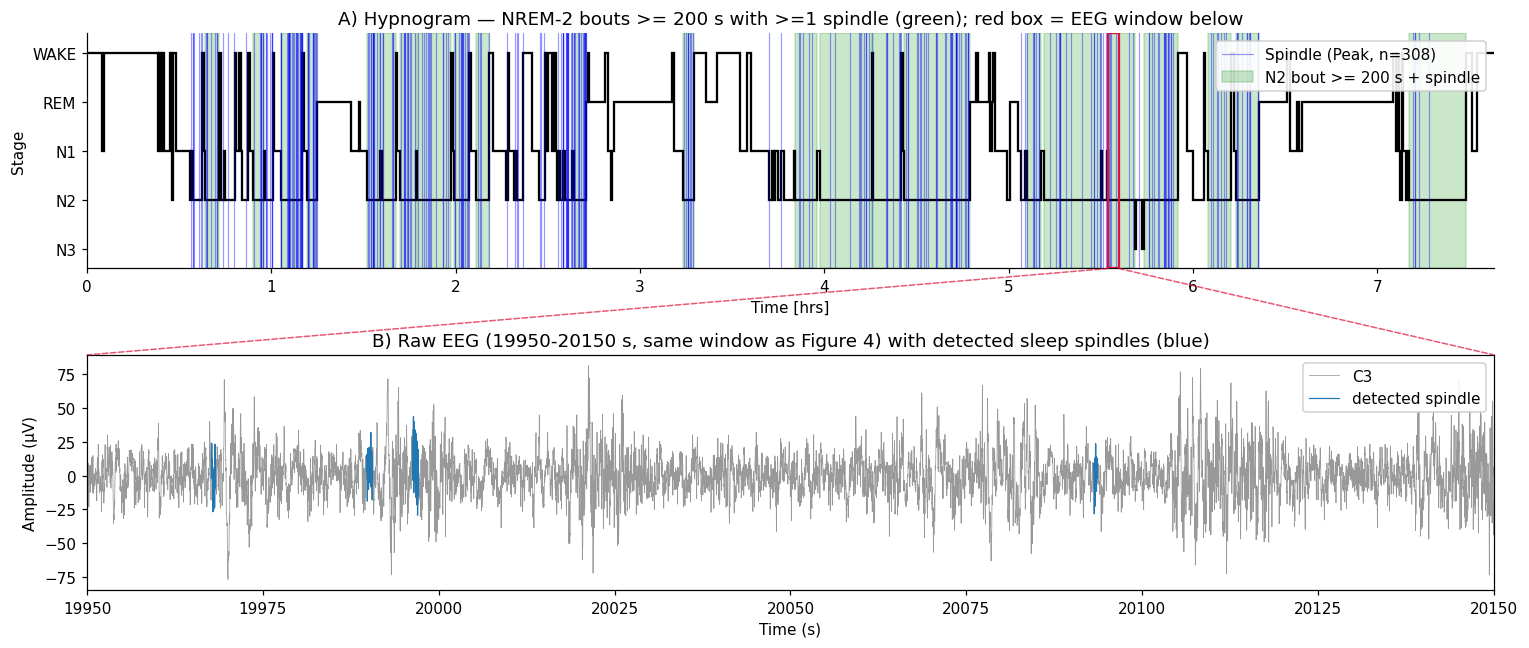

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6))
w0, w1 = WIN                                     # same window as Figure 4

# --- Top: hypnogram, N2 bouts >= MIN_BOUT_SEC shaded green (x-axis is in hours) ---
plot_hypnogram(loader, spindles=sp, highlight=None, ax=axes[0], mark_color='blue')
for k, (a, b) in enumerate(bouts):
    axes[0].axvspan(a / 3600, b / 3600, color='tab:green', alpha=0.25, zorder=0,
                    label=f'N2 bout >= {MIN_BOUT_SEC} s + spindle' if k == 0 else None)

# --- Mark the WIN window (shared with Figure 4) on the hypnogram ---
axes[0].axvspan(w0 / 3600, w1 / 3600, facecolor='none', edgecolor='crimson',
                lw=1.5, zorder=6)
axes[0].set_title(f'A) Hypnogram — NREM-2 bouts >= {MIN_BOUT_SEC} s with >=1 spindle (green); red box = EEG window below')
axes[0].legend(loc='upper right', frameon=True, framealpha=0.9)

# --- Bottom: raw EEG over the WIN window (grey) with spindles in blue ---
t = np.arange(len(data)) / sf
m = (t >= w0) & (t <= w1)
axes[1].plot(t[m], data[m], color='0.6', lw=0.5, label='C3')
in_win = (starts < w1) & (ends > w0)
first = True
for s0, e0 in zip(starts[in_win], ends[in_win]):
    seg = (t >= s0) & (t <= e0)
    axes[1].plot(t[seg], data[seg], color=BLUE, lw=0.8,
                 label='detected spindle' if first else None)
    first = False
axes[1].set(xlim=(w0, w1), xlabel='Time (s)', ylabel='Amplitude (µV)',
            title=f'B) Raw EEG ({w0:.0f}-{w1:.0f} s, same window as Figure 4) '
                  'with detected sleep spindles (blue)')
axes[1].legend(loc='upper right', frameon=True, framealpha=0.9)

# --- Red dashed connectors from the hypnogram window down to the EEG axes ---
y_hyp = axes[0].get_ylim()[0]
y_eeg = axes[1].get_ylim()[1]
for x in (w0, w1):
    fig.add_artist(ConnectionPatch(
        xyA=(x / 3600, y_hyp), coordsA=axes[0].transData,
        xyB=(x, y_eeg), coordsB=axes[1].transData,
        color='crimson', lw=1.0, ls='--', alpha=0.7))

fig.tight_layout()

## Sigma-filter envelope (Figure 4 input)

Morlet wavelets analytic power (FFT domain) of the 11–16 Hz band, averaged into 1 s bins. We keep both the
**dB** course.

In [16]:
t_env, sigma_db = eeg_envelope(
    data, sf, band=SIGMA_BAND, sf_env=DEFAULT_SF_ENV, smooth_sec=1, wavelet=True, to_db=True, kind='power',
)

def env_at(times, t=t_env, y=sigma_db):
    """Envelope (power or amplitude, matching sigma_db) value interpolated at spindle
    peak times (for the blue dots) -- matches the plotted curve's own y-axis, not
    YASA's own per-spindle Amplitude summary column."""
    return np.interp(times, t, y)

## Figure 4 — Sigma EEG envelope (C3)

The sigma-eeg envelope (10-16 Hz) course over the **selected N2 bout** (`BOUT_IDX`, the same bout
Figure 3 zooms into), restricted to the same `WIN` window, in grey, with each detected
spindle marked as a blue dot at its peak time.

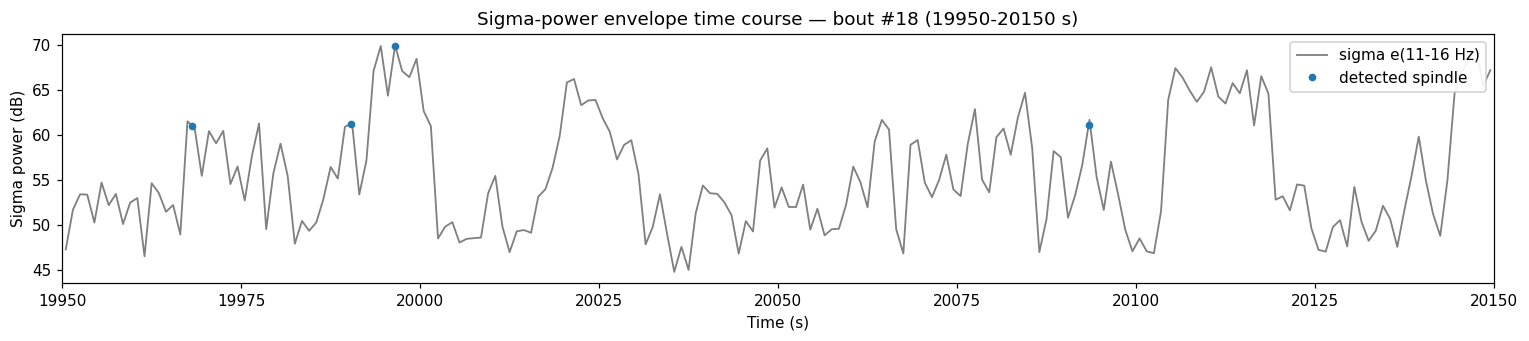

In [17]:
fig, ax = plt.subplots(figsize=(14, 3.2))
me = (t_env >= WIN[0]) & (t_env <= WIN[1])
ax.plot(t_env[me], sigma_db[me], color='0.5', lw=1.2, label='sigma e(11-16 Hz)')
pk = peaks[(peaks >= WIN[0]) & (peaks <= WIN[1])]
ax.plot(pk, env_at(pk), 'o', color=BLUE, ms=4, label='detected spindle')
ax.set(xlim=WIN, xlabel='Time (s)', ylabel='Sigma power (dB)',
       title=f'Sigma-power envelope time course — bout #{BOUT_IDX} ({WIN[0]:.0f}-{WIN[1]:.0f} s)')
ax.legend(loc='upper right', frameon=True, framealpha=0.9)
fig.tight_layout()

## Figure 5 — relative spectral power, baseline correction & bi-Gaussian fit

The relative spectral power is the mean Welch spectrum of the sigma-power course across all
bouts, normalized to unit in-band area. Baseline correction subtracts the mean power over
0.06–0.1 Hz (red line). A bi-Gaussian (separate left/right SDs, capturing the asymmetric
steep-rise/slow-decay shape real infraslow spectra show) is fit to the corrected spectrum;
if its peak exceeds the threshold (1.5 × the noise SD in the baseline band) the ISFS is
detected and its peak frequency, bandwidth (**left + right SD**, i.e. -1 SD to +1 SD around
the peak) and area under the curve (power within that **same range**) are estimated.

In [18]:
# One Welch spectrum per bout on a common frequency grid, then averaged.
segs = [sigma_db[(t_env >= a) & (t_env < b)] for a, b in bouts]
segs = [s for s in segs if len(s) >= 64]
# wsec = min(len(s) for s in segs)                       # identical freq grid for all bouts
specs = [infraslow_spectrum(s, DEFAULT_SF_ENV, window_sec=WINDOW_SEC)
         for s in segs]
freqs = specs[0].freqs
mean_psd = np.mean([sp_.psd for sp_ in specs], axis=0)
band_m = (freqs >= INFRASLOW_BAND[0]) & (freqs <= INFRASLOW_BAND[1])

# Relative spectral power (unit in-band area) and baseline correction over 0.06-0.1 Hz --
# both from infraslow.processing.infraslow, shared with subject_pipeline.py's own
# per-bout/per-stage spectra so the two can't drift apart.
rel = relative_power(mean_psd, freqs, INFRASLOW_BAND)
corrected = baseline_correct(rel, freqs, BASELINE_BAND)

# Per-bout relative spectra (each bout's own unit-band-area normalization) -- feeds
# Figure 5A's individual bout lines and the mean +/- SD (between-bout variability) band.
psd_all = np.array([sp_.psd for sp_ in specs])
rel_all = relative_power(psd_all, freqs, INFRASLOW_BAND)
rel_sd = rel_all.std(axis=0, ddof=1)

# Real (empirical) spectral peak -- the raw argmax within the infraslow band, before
# any bi-Gaussian fitting. Baseline correction is just a constant vertical shift, so
# this lands on the same frequency in both `rel` (Fig 5A) and `corrected` (Fig 5B);
# plotted in both panels for comparison against the fit's own peak (`mu`) in Fig 5B.
real_peak_idx = np.argmax(rel[band_m])
real_peak_freq = float(freqs[band_m][real_peak_idx])

# Bi-Gaussian fit over the ISFS candidate range (below the baseline band): separate
# left/right SDs capture the asymmetric (steep rise, slow decay) shape real infraslow
# spectra show, which pulls a symmetric Gaussian away from the true peak.
fit = fit_isfs(freqs, corrected, infraslow_band=INFRASLOW_BAND, baseline_band=BASELINE_BAND)
popt, amp, mu = fit['popt'], fit['amp'], fit['mu']
lo, hi, bandwidth = fit['lo'], fit['hi'], fit['bandwidth']
auc, threshold, detected = fit['auc'], fit['threshold'], fit['detected']
f_auc = np.linspace(lo, hi, 400)     # matches fit_isfs's own AUC integration grid

print(f'ISFS detected: {detected} | peak {mu:.4f} Hz (~{1/mu:.0f} s) | '
      f'bandwidth {bandwidth:.4f} Hz (+/-1 SD: {lo:.4f}-{hi:.4f}) | AUC {auc:.3g} | '
      f'real (empirical) peak {real_peak_freq:.4f} Hz (~{1/real_peak_freq:.0f} s)')

ISFS detected: True | peak 0.0200 Hz (~50 s) | bandwidth 0.0287 Hz (+/-1 SD: 0.0104-0.0391) | AUC 0.406 | real (empirical) peak 0.0200 Hz (~50 s)


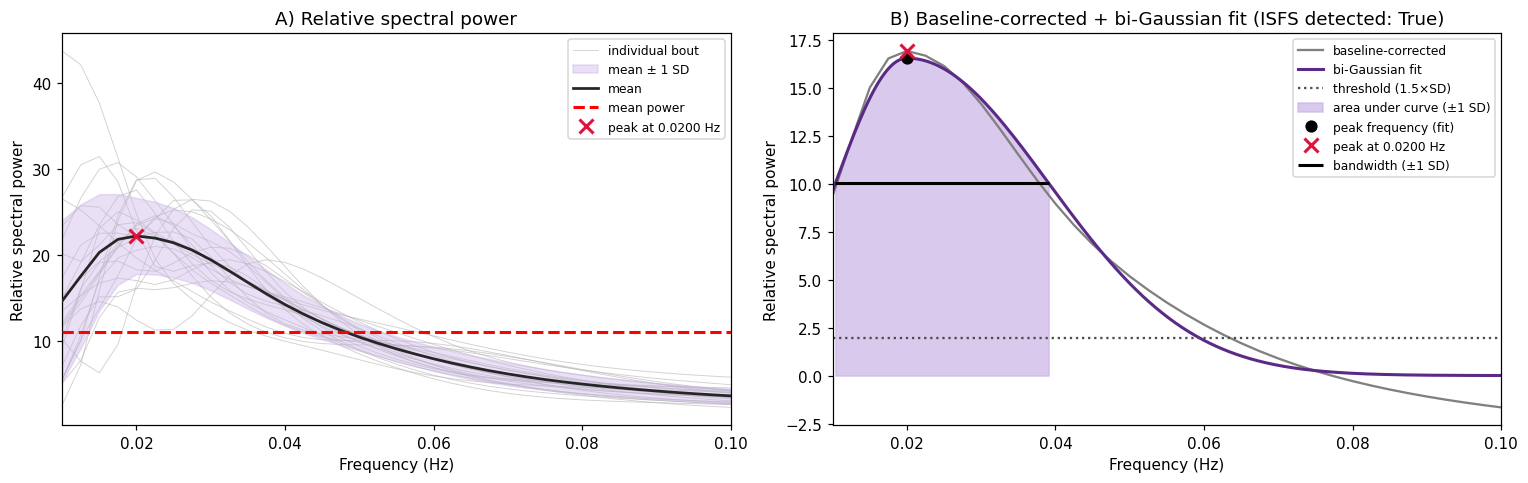

In [19]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(14, 4.5))

# --- Left: relative spectral power -- each bout's own curve (thin grey), the
# across-bout mean +/- 1 SD band, and the mean power level (red) ---
for i in range(rel_all.shape[0]):
    axL.plot(freqs[band_m], rel_all[i, band_m], color='0.7', lw=0.6, alpha=0.6, zorder=1,
             label='individual bout' if i == 0 else None)
axL.fill_between(freqs[band_m], (rel - rel_sd)[band_m], (rel + rel_sd)[band_m],
                 color=LPURPLE, alpha=0.4, zorder=2, label='mean ± 1 SD')
axL.plot(freqs[band_m], rel[band_m], color='0.15', lw=1.8, zorder=3, label='mean')
mean_power = rel[band_m].mean()
axL.axhline(mean_power, color='red', lw=2, ls='--', zorder=4, label='mean power')
axL.plot([real_peak_freq], [rel[band_m][real_peak_idx]], 'x', color='crimson', ms=9,
         mew=2, zorder=6, label=f'peak at {real_peak_freq:.4f} Hz')
axL.set(xlim=INFRASLOW_BAND, xlabel='Frequency (Hz)', ylabel='Relative spectral power',
        title='A) Relative spectral power')
axL.legend(frameon=True, fontsize=8)

# --- Right: baseline-corrected spectrum + bi-Gaussian fit + ISFS parameters ---
axR.plot(freqs[band_m], corrected[band_m], color='0.5', lw=1.5, label='baseline-corrected')
fg = np.linspace(*INFRASLOW_BAND, 400)
axR.plot(fg, bigaussian(fg, *popt), color=PURPLE, lw=2, label='bi-Gaussian fit')
axR.axhline(threshold, ls=':', color='0.3', label='threshold (1.5×SD)')
axR.fill_between(f_auc, bigaussian(f_auc, *popt), color=LPURPLE, alpha=0.7,
                 label='area under curve (±1 SD)')
axR.plot([mu], [bigaussian(mu, *popt)], 'o', color='k', ms=7, zorder=5, label='peak frequency (fit)')
axR.plot([real_peak_freq], [corrected[band_m][real_peak_idx]], 'x', color='crimson', ms=9,
         mew=2, zorder=6, label=f'peak at {real_peak_freq:.4f} Hz')
axR.hlines(bigaussian(lo, *popt), lo, hi, color='k', lw=2, label='bandwidth (±1 SD)')
axR.set(xlim=INFRASLOW_BAND, xlabel='Frequency (Hz)', ylabel='Relative spectral power',
        title=f'B) Baseline-corrected + bi-Gaussian fit (ISFS detected: {detected})')
axR.legend(frameon=True, fontsize=8)
fig.tight_layout()

## Figure 6 — distribution of peak frequency across bouts

Histogram of each individual N2 bout's own within-band relative-power peak frequency
(argmax of `rel_all`, Figure 5's per-bout relative spectra, from `specs`), showing how
consistent the ISFS peak frequency is bout-to-bout. Figure 5's across-bout mean-spectrum
peak (`real_peak_freq`) and bi-Gaussian fit peak (`mu`) are marked for reference.

Fig 6: 23 bout(s), each its own in-band relative-power peak


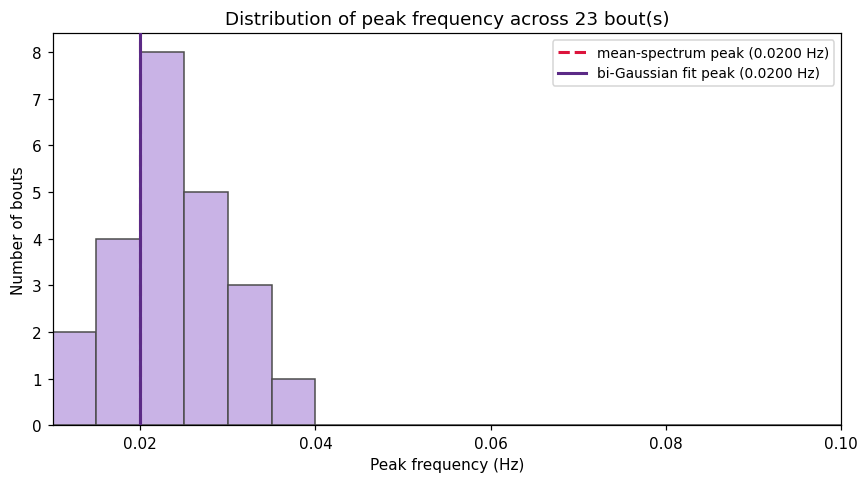

In [20]:
bout_peak_freqs = freqs[band_m][np.argmax(rel_all[:, band_m], axis=1)]

fig, ax = plt.subplots(figsize=(8, 4.5))
bin_w = 0.005
bins = np.arange(INFRASLOW_BAND[0], INFRASLOW_BAND[1] + bin_w, bin_w)
ax.hist(bout_peak_freqs, bins=bins, color=LPURPLE, edgecolor='0.3', zorder=2)
ax.axvline(real_peak_freq, color='crimson', lw=2, ls='--', zorder=4,
           label=f'mean-spectrum peak ({real_peak_freq:.4f} Hz)')
ax.axvline(mu, color=PURPLE, lw=2, ls='-', zorder=4, label=f'bi-Gaussian fit peak ({mu:.4f} Hz)')
ax.set(xlim=INFRASLOW_BAND, xlabel='Peak frequency (Hz)', ylabel='Number of bouts',
       title=f'Distribution of peak frequency across {len(bout_peak_freqs)} bout(s)')
ax.legend(frameon=True, fontsize=9)
fig.tight_layout()

print(f'Fig 6: {len(bout_peak_freqs)} bout(s), each its own in-band relative-power peak')

In [21]:
specs[0]

InfraslowSpectrum(freqs=array([0.0025, 0.005 , 0.0075, 0.01  , 0.0125, 0.015 , 0.0175, 0.02  ,
       0.0225, 0.025 , 0.0275, 0.03  , 0.0325, 0.035 , 0.0375, 0.04  ,
       0.0425, 0.045 , 0.0475, 0.05  , 0.0525, 0.055 , 0.0575, 0.06  ,
       0.0625, 0.065 , 0.0675, 0.07  , 0.0725, 0.075 , 0.0775, 0.08  ,
       0.0825, 0.085 , 0.0875, 0.09  , 0.0925, 0.095 , 0.0975, 0.1   ]), psd=array([280.78421744, 344.98006981, 432.14595065, 517.14201895,
       568.97312558, 565.50936059, 520.99229636, 489.64565832,
       534.01129478, 582.91304519, 584.26622318, 543.58375301,
       480.4240111 , 412.81733209, 352.10129817, 302.66489329,
       264.11145037, 233.91394279, 209.33621254, 188.33385968,
       169.71376435, 152.93800139, 137.84660851, 124.43315069,
       112.70979059, 102.64814768,  94.16685964,  87.13995189,
        81.4107309 ,  76.80459005,  73.14002455,  70.23744398,
        67.92679442,  66.05370795,  64.4839986 ,  63.10624955,
        61.83259455,  60.59785095,  59.35739499,